In [1]:
#tsne

In [2]:
import tensorflow as tf 
import numpy as np 
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.manifold import TSNE 
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

In [3]:
dataset_path = "../cv_lab/Mar 11/caltech101"
categories = ['ant', 'accordion']

In [4]:
base_model=ResNet50(weights="imagenet",include_top=False,pooling="avg")
model=Model(inputs=base_model.input,outputs=base_model.output)

In [5]:
def extract_features(img_path):
    images=image.load_img(img_path)
    images = image.img_to_array(images)
    images = np.expand_dims(images, axis=0)
    images = preprocess_input(images) 
    features = model.predict(images, verbose=0)
    return features.flatten()

In [7]:
features=[]
labels=[]
dataset_path = "../cv_lab/Mar 11/caltech101"
categories = ['ant', 'accordion']

for img in os.listdir(dataset_path):
    if img not in categories:
        continue
    img_path = os.path.join(dataset_path, img)
    for img2 in tqdm(os.listdir(img_path)):
        img2_path = os.path.join(img_path, img2)
        feats = extract_features(img2_path)
        features.append(feats)
        labels.append(img)

features = np.array(features)
print("Total images processed: ", len(features))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../cv_lab/Mar 11/caltech101'

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

AttributeError: 'list' object has no attribute 'shape'

C:\Users\lapto\AppData\Local\Temp\ipykernel_2992\3525019408.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


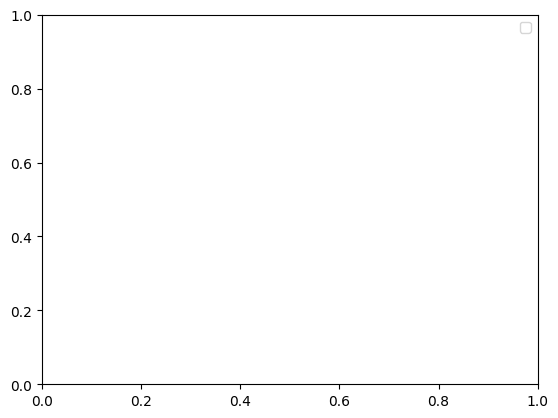

In [ ]:
unique_labels = list(set(labels))
for label in unique_labels:
    indices = [i for i in range(len(labels)) if label == labels[i]]
    plt.scatter(features_2d[indices, 0], features_2d[indices, 1], label=label, alpha = 0.7)

plt.legend()
plt.show()